# **1. Perkenalan Dataset**


Saya menggunakan dataset California Housing Prices yang saya ambil dari platform Kaggle untuk keperluan eksperimen pelatihan model saya. Dataset ini berisi metrik perumahan yang bersumber dari hasil Sensus California tahun 1990, di mana datanya merepresentasikan agregat statistik per blok sensus, bukan data rumah secara individu. Tujuan utama saya menggunakan dataset ini adalah untuk melatih machine learning agar mampu memprediksi nilai tengah harga rumah (median_house_value) di suatu area dengan mempelajari pola dari fitur-fitur yang ada, seperti lokasi geografis, usia rata-rata bangunan, jumlah kamar, kedekatan dengan laut, hingga tingkat rata-rata pendapatan masyarakat setempat.

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# **3. Memuat Dataset**

In [2]:
file_id = '13CH1nErq2Grw691XgqPLidTwwqLgOZtV'
url = f'https://drive.google.com/uc?id={file_id}'

print("Mengunduh dan membaca dataset...")
df = pd.read_csv(url)
print(f"Dataset berhasil dimuat dengan ukuran: {df.shape}")

Mengunduh dan membaca dataset...
Dataset berhasil dimuat dengan ukuran: (20640, 10)


In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# **4. Exploratory Data Analysis (EDA)**

In [4]:
sns.set_theme(style="whitegrid")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
display(df.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


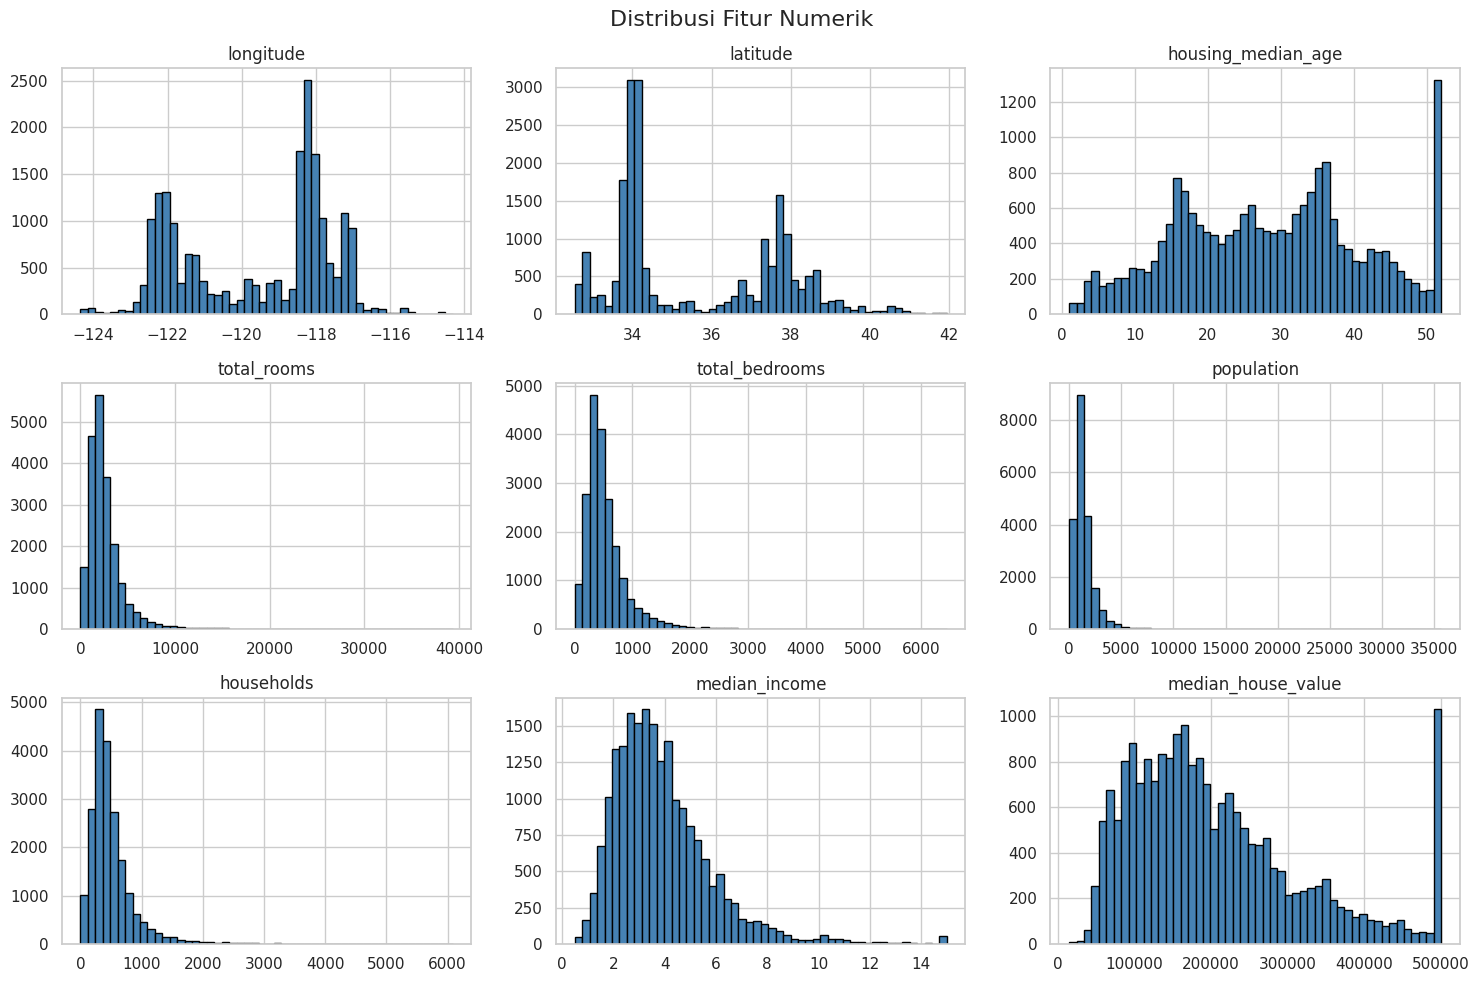

In [7]:
#Visualisasi Distribusi Fitur Numerik
df.hist(bins=50, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik', fontsize=16)
plt.tight_layout()
plt.show()

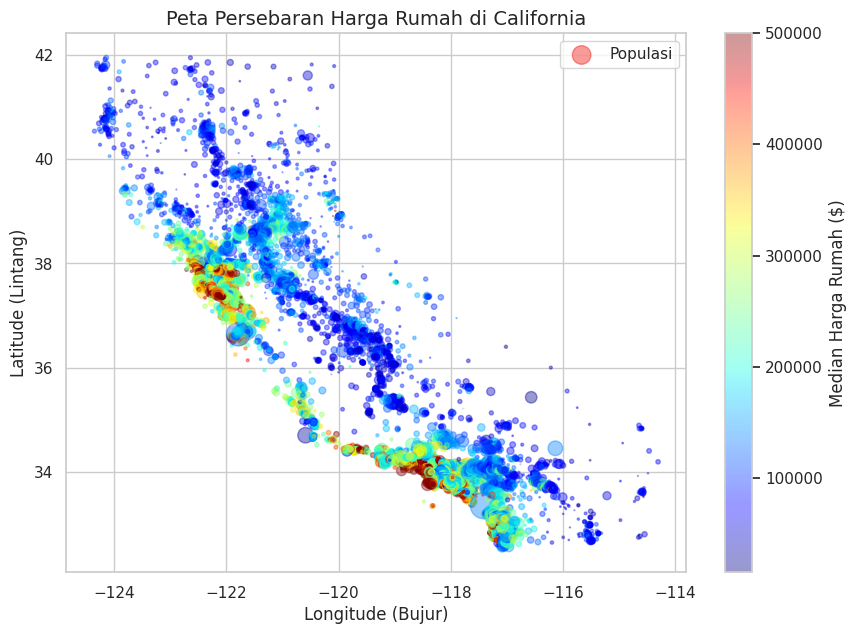

In [8]:
#Visualisasi Geografis (Peta Harga Rumah)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(x=df['longitude'],
                      y=df['latitude'],
                      alpha=0.4,
                      s=df['population']/100, label='Populasi',
                      c=df['median_house_value'], cmap=plt.get_cmap('jet'))

plt.colorbar(scatter, label='Median Harga Rumah ($)')
plt.xlabel('Longitude (Bujur)')
plt.ylabel('Latitude (Lintang)')
plt.title('Peta Persebaran Harga Rumah di California', fontsize=14)
plt.legend()
plt.show()

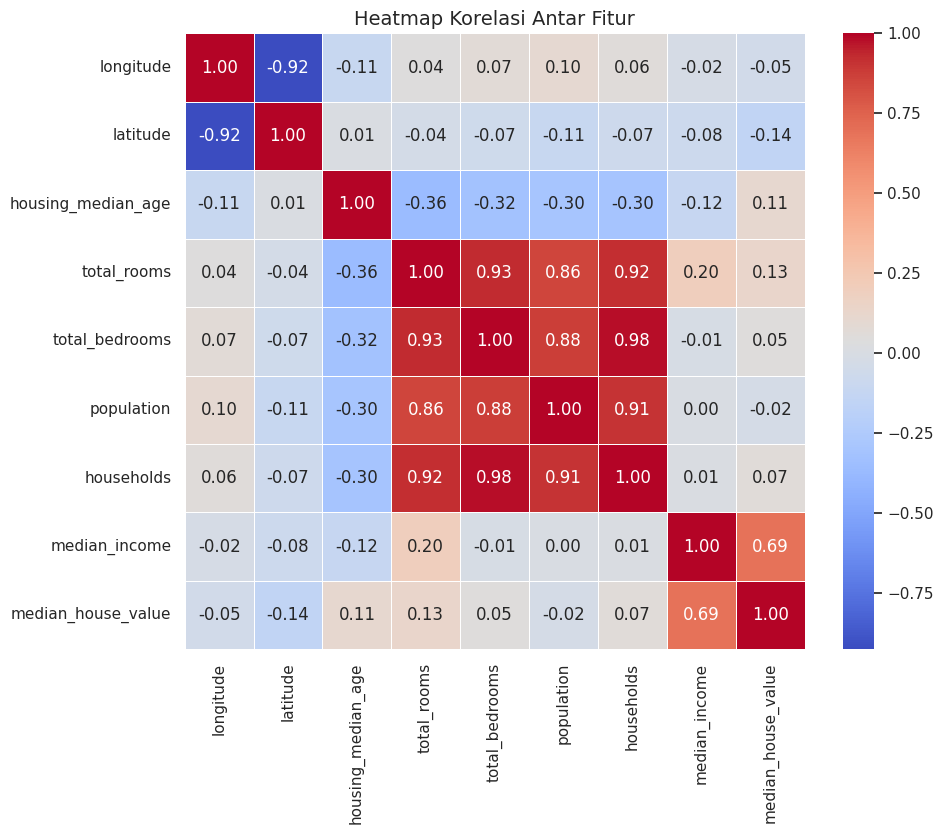

In [9]:
#Analisis Korelasi (Mencari Fitur Terpenting)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.show()

/tmp/ipykernel_2488/4025507041.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ocean_proximity', palette='viridis')


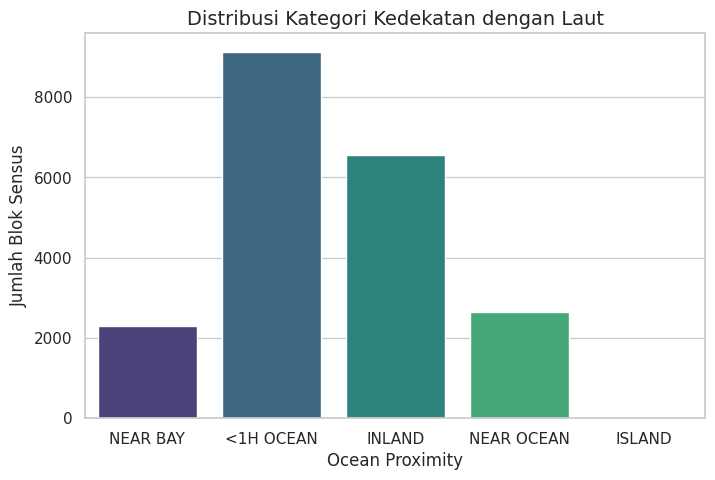

In [10]:
#Analisis Fitur Kategorikal
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ocean_proximity', palette='viridis')
plt.title('Distribusi Kategori Kedekatan dengan Laut', fontsize=14)
plt.ylabel('Jumlah Blok Sensus')
plt.xlabel('Ocean Proximity')
plt.show()

# **5. Data Preprocessing**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
#Tahap 1: Menghapus Data Duplikat
df = df.drop_duplicates()
print(f"Ukuran data setelah hapus duplikat: {df.shape}")

Ukuran data setelah hapus duplikat: (20640, 10)


In [13]:
#Tahap 2: Deteksi dan Penanganan Outlier
Q1 = df['median_income'].quantile(0.25)
Q3 = df['median_income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['median_income'] >= lower_bound) & (df['median_income'] <= upper_bound)]
print(f"Ukuran data setelah penanganan outlier: {df.shape}")


Ukuran data setelah penanganan outlier: (19959, 10)


In [14]:
# Tahap 3: Menangani Data Kosong (Missing Values)
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [15]:
# Tahap 4: Feature Engineering
print("Melakukan Feature Engineering...")

# 1. Membuat Fitur Rasio
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# Menghapus nilai tak hingga (inf) jika ada pembagian dengan nol
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Mengisi nan hasil pembagian dengan median
df['bedrooms_per_room'] = df['bedrooms_per_room'].fillna(df['bedrooms_per_room'].median())
df['rooms_per_household'] = df['rooms_per_household'].fillna(df['rooms_per_household'].median())
df['population_per_household'] = df['population_per_household'].fillna(df['population_per_household'].median())

# 2. Membuat Fitur Klaster Geografis (Spasial)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
coords = df[['latitude', 'longitude']]
df['cluster_location'] = kmeans.fit_predict(coords)

# Ubah ke string agar diproses sebagai kategori saat One-Hot Encoding
df['cluster_location'] = df['cluster_location'].astype(str)

# 3. Membuang fitur absolut yang memicu multikolinearitas
df = df.drop(['total_rooms', 'total_bedrooms', 'population', 'households'], axis=1)

print(f"Ukuran data setelah Feature Engineering: {df.shape}")

Melakukan Feature Engineering...
Ukuran data setelah Feature Engineering: (19959, 10)


In [16]:
# Tahap 5: Encoding Data Kategorikal
df = pd.get_dummies(df, columns=['ocean_proximity', 'cluster_location'], dtype=int)

In [17]:
# Persiapan Pemisahan Data (Mencegah Data Leakage)
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Tahap 6: Normalisasi / Standarisasi Fitur
num_cols = ['longitude', 'latitude', 'housing_median_age', 'median_income',
            'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

scaler = StandardScaler()

# Melakukan 'fit' dan 'transform' HANYA pada data latih
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Melakukan 'transform' (menggunakan pola data latih) pada data uji
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nData preprocessing & Feature Engineering selesai!")
print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")


Data preprocessing & Feature Engineering selesai!
Bentuk X_train: (15967, 22)
Bentuk X_test: (3992, 22)


# **6. Penyimpanan Data**

In [20]:
# Menggabungkan kembali fitur (X) dan target (y)
train_processed = X_train.copy()
train_processed['median_house_value'] = y_train

test_processed = X_test.copy()
test_processed['median_house_value'] = y_test

# Menyimpan menjadi file CSV
train_processed.to_csv('housing_train_preprocessing.csv', index=False)
test_processed.to_csv('housing_test_preprocessing.csv', index=False)

print("Dataset berhasil disimpan ke 'housing_train_preprocessing.csv' dan 'housing_test_preprocessing.csv'!")

Dataset berhasil disimpan ke 'housing_train_preprocessing.csv' dan 'housing_test_preprocessing.csv'!
